###### <img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

# <font color="navy">ANÁLISIS EXPLORATORIO DE DATOS (EDA), PREPROCESAMIENTO, EXPLORACIÓN ANALÍTICA EXHAUSTIVA Y CONSTRUCCIÓN ISDE - NIVEL MICRO</font>  
## <font color="lightblue">*Cuestionario LIKERT de competencia Digital Docente (elaboración propia)*</font> 
## TFM: Construcción de un Índice Sintético de Digitalización Educativa (ISDE) mediante Análisis Exploratorio de Datos, Aprendizaje Automático no Supervisado y Analítica Visual. Análisis comparado basado en datos abiertos europeos.

### Máster en Análisis y Visualización de Datos Masivos - UNIR

---

**Autores:** José Miguel Martínez Martín & Rocío Noriega Bustelo  
**Fecha:** Febrero 2026

---

## Consideraciones Éticas

>- El dataset original no se distribuye públicamente por motivos de protección de datos conforme al Reglamento (UE) 2016/679 (RGPD) y la Ley Orgánica 3/2018 (LOPDGDD).
>- Para garantizar la replicabilidad académica, se facilita versión anonimizada bajo solicitud formal a los autores.

---
# 1. Configuración inicial y EDA
---

## 1.1 Importación de librerías y configuración inicial base
### Justificación
Se importan únicamente librerías necesarias para:
>- Manipulación de datos
>- Estadística descriptiva
>- Visualización
>- Estandarización

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import skew, kurtosis, pearsonr
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuración inicial base
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## 1.2 Carga del dataset (local)
El dataset no se distribuye públicamente por motivos de protección de datos.

In [2]:
# 2. CARGA LOCAL DEL DATASET

ruta_dataset = "C:/Users/ROCIO/OneDrive - UNIR/Documentos/TFM_TICs/Construccion-de-un-Indice-Sintetico-de-Digitalizacion-Educativa-ISDE/data/Respuestas_Cuestionario_Docente_TICs.csv"

if os.path.exists(ruta_dataset):
    df = pd.read_csv(ruta_dataset)
    print("Dataset cargado correctamente.")
    print("Dimensiones:", df.shape)
else:
    raise FileNotFoundError(
        "Archivo no encontrado. "
        "Por razones de protección de datos no se distribuye públicamente."
    )

df.head()

Dataset cargado correctamente.
Dimensiones: (45, 24)


,Marca temporal,Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).","Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).","Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).","Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",...,Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital.,"Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela).",18. Indique hasta tres barreras principales que encuentra para integrar TICs en su docencia.,19. Describa una buena práctica con TIC implementada en su aula/centro en los últimos 12 meses.,20. ¿Qué apoyos formativos o materiales considera prioritarios para mejorar la integración de TICs?,Curso escolar de secundaria:,Nombre del centro. Municipio o localidad. Provincia,Ítem 16 — Valoración del profesorado sobre si el uso de las TICs ha mejorado el rendimiento académico del alumnado.,Ítem 17 — Valoración del profesorado sobre si la implantación de las TICs ha sido efectiva en su práctica docente.,Columna 2
0,20/10/2025 22:28:27,1,2,3,3.0,4,2,1,1.0,3,...,3,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21/10/2025 14:46:34,5,2,1,3.0,4,3,4,2.0,2,...,4,1.0,Las principales barreras para la aplicación ef...,Una buena práctica TIC en mi centro consiste e...,Un apoyo prioritario para el uso eficaz de las...,4º ESO,NaN,NaN,NaN,NaN
2,21/10/2025 14:50:44,5,5,5,3.0,4,4,4,3.0,5,...,4,4.0,"Adaptación de los estudiantes, diferenciación ...",Gamification,Entrenamientos en herramientas para clases más...,4º ESO,NaN,NaN,NaN,NaN
3,21/10/2025 19:32:41,4,3,3,4.0,3,3,3,4.0,4,...,3,4.0,Algunos fallos de conexión. Siempre una opción...,Presentaciones de personajes importantes por m...,Necesidad de horas para el coordinador/a tde,3º ESO,IES Los Molinos Conil. CÁDIZ,NaN,NaN,NaN
4,21/10/2025 20:24:08,4,4,3,3.0,3,3,4,3.0,4,...,3,3.0,"Poca formación,falta de tiempo, problemas para...",El alumnado de 1° elaboran sus propios kahoot ...,Necesidad de que todos los alumnos dispongan d...,1º ESO,IES Roche.Conil.Cádiz,NaN,NaN,NaN


## 1.3 Inspección inicial
### Objetivo
> Comprender estructura, tipos y posibles inconsistencias.

In [3]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 24 columns):
 #   Column                                                                                                                          Non-Null Count  Dtype  
---  ------                                                                                                                          --------------  -----  
 0   Marca temporal                                                                                                                  45 non-null     object 
 1   Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                            45 non-null     int64  
 2   Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                            45 non-null     int64  
 3   Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.          

Marca temporal                                                                                                                     0
Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                               0
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                               0
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                  0
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                           1
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                       0
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                        0
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbric

**NÚMERO DE VALORES NULOS POR COLUMNA, ORDENADO DE MAYOR A MENOR:**

In [4]:
df.isnull().sum().sort_values(ascending=False)

Columna 2                                                                                                                         45
Ítem 17 — Valoración del profesorado sobre si la implantación de las TICs ha sido efectiva en su práctica docente.                35
Ítem 16 — Valoración del profesorado sobre si el uso de las TICs ha mejorado el rendimiento académico del alumnado.               35
Nombre del centro. Municipio o localidad. Provincia                                                                               11
20. ¿Qué apoyos formativos o materiales considera prioritarios para mejorar la integración de TICs?                               10
19. Describa una buena práctica con TIC implementada en su aula/centro en los últimos 12 meses.                                   10
18. Indique hasta tres barreras principales que encuentra para integrar TICs en su docencia.                                      10
Ítem 4 — Formación recibida en competencias digitales pedagógicas en 

Como la muestra tiene 45 observaciones (docentes):
>- 45 nulos = columna completamente vacía
>- 35 nulos = respondida solo por 10 personas
>- 11 nulos = respondida por 34 personas
>- 1 nulo = prácticamente completa
>- 0 nulos = completa
>

### Hallazgos e interpretación técnica:
1. **Columna 2:** tiene 45 valores nulos. Está completamente vacía. No contiene información útil.
>- **Conclusión metodológica:** Debe eliminarse inmediatamente.

2. **Ítems 16 y 17** → 35 nulos.
>- **Significado:** Solo 10 respuestas válidas. 35 docentes no respondieron. Esto NO es “completamente vacío”. Es **alto porcentaje de no respuesta (77.8%)**.
>- **Cálculo:** 35/45=0.777≈78%.
>- **Interpretación metodológica:** Puede deberse a:
> >- (i) Preguntas añadidas al final,
> >- (ii) Fatiga del encuestado,
> >- (iii) Error en el formulario,
> >- (iv) Pregunta opcional (de hecho, son todas opcionales a excepción de las dos cuestiones iniciales: del curso escolar y del centro, localidad y provincia)
>- **Decisión técnica más adecuada:** Si el nivel de *no respuesta* **> 50%**, en estudios de escala Likert:
> >- (i) Es recomendable eliminar del análisis cuantitativo,
> >- (ii) O bien, analizarlos por separado
>- **Motivo:**
>>- Distorsionan medias
>>- Reducen potencia estadística
>>- Pueden sesgar resultados

3. **Variables abiertas (18, 19, 20)** → 10 nulos.
>- **Significado:** 35 respuestas válidas. 10 personas no respondieron. Esto es normal en preguntas abiertas. **No se eliminan, se tratan cualitativamente.** No afectan al análisis Likert.
>- Si bien, dado que:
>>- Es cuestionario propio
>>- Muestra pequeña (45 docentes)
>>- Sector educativo (sensible)
>>- Posible identificación indirecta
>- Se opta por:
>>- Subir versión anonimizada (previa solicitud expresa a los autores)
>>- Eliminar, finalmente, las variables contextuales
>>- Mantener solo Likert
>>- Publicar solo dataset procesado (sin respuestas abiertas)

4. **“Nombre del centro”** → 11 nulos. **Esto es crítico.**
>- **Significa:** 34 personas sí identificaron centro. 11 no lo hicieron.
>- **Problema:** Esto es dato potencialmente identificable. Con 45 docentes, la reidentificación indirecta es posible.
>- **Desde perspectiva RGPD:** Debe eliminarse antes de cualquier publicación o análisis compartido.

df = df.drop(columns=["Nombre del centro. Municipio o localidad. Provincia"])

5. **Ítems con 1 nulo**
>- **Ejemplo:** Ítem 4 → 1 nulo; Ítem 8 → 1 nulo; Ítem 14 → 1 nulo; Curso escolar → 1 nulo
>- **Esto es insignificante (2.2% de la muestra)**.
>- **Opciones:**
>> A) Imputar con mediana\
>> B) Eliminar esa fila\
>> C) Mantener NaN si el impacto es mínimo\
>> **En Likert con muestra pequeña (n=45) es recomendable imputación por mediana**:

df_likert = df_likert.fillna(df_likert.median())

>- **Justificación:** Evita pérdida de potencia estadística.

6. **Ítems con 0 nulos**
>- Perfectamente completos
>- No requieren tratamiento.

### Resumen Hallazgos y decisiones definitivas:
>- Ítems 16 y 17 → mayoritariamente vacíos
>- Columna 2 → vacía
>- Variables abiertas con valores faltantes
>- Veriable *"Nombre del centro"* cuya reidentificación indirecta es posible.
>- Decisión metodológica:
>>- Se eliminarán columnas completamente vacías y mayoritariamente vacías
>>- Se eliminará la variable *"Nombre del centro"* (ajustándose a la normativa RGPD)
>>- Se mantendrán variables abiertas para análisis cualitativo posterior
>>
<div align="center">

### RESUMEN TÉCNICO DE LOS HALLAZGOS

</div>

| Tipo de variable   | Situación          | Acción recomendada              |
| ------------------ | ------------------ | ------------------------------- |
| Columna 2          | 100% nulos         | Eliminar                        |
| Ítems 16-17        | 78% nulos          | Eliminar del análisis principal |
| Variables abiertas | 22% nulos          | Mantener (análisis cualitativo) |
| Nombre centro      | Dato identificable | Eliminar                        |
| Ítems con 1 nulo   | 2%                 | Imputar mediana                 |
| Ítems completos    | 0%                 | Mantener                        |

---
# 2. Limpieza y preprocesamiento
---

## 2.1 Eliminación de columnas completamente vacías
### Justificación
Columnas vacías no aportan información y distorsionan análisis.

In [5]:
df = df.dropna(axis=1, how='all')
df.isnull().sum()

Marca temporal                                                                                                                     0
Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                               0
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                               0
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                  0
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                           1
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                       0
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                        0
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbric

## 2.2 Eliminación de columnas mayoritariamente vacías y columna con datos sensible (RGPD)

In [6]:
# Ver columnas antes
print("Columnas antes de eliminar:")
print(df.columns)

# Columnas que se eliminarán:
df.columns = df.columns.str.strip()

cols_to_drop = [col for col in df.columns 
                if "Ítem 16" in col 
                or "Ítem 17" in col 
                or "Nombre del centro" in col]

print("Columnas que se eliminarán:", cols_to_drop)

# Eliminar columnas que contengan ciertos textos clave
df = df.drop(columns=[col for col in df.columns 
                      if "Ítem 16" in col 
                      or "Ítem 17" in col 
                      or "Nombre del centro" in col],
             errors="ignore")

# Mostrar columnas después
print("\nColumnas después de eliminar:")
print(df.columns)

Columnas antes de eliminar:
Index(['Marca temporal',
       'Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.',
       'Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).',
       'Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.',
       'Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.',
       'Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.',
       'Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).',
       'Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).',
       'Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).',
       'Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqu

## 2.3 Selección de ítems Likert (Variables Cuantitativas)
### Justificación
Identificamos los ítems 1–15.

In [7]:
likert_cols = [col for col in df.columns if "Ítem" in col]
df_likert = df[likert_cols]

df_likert.head()

,Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).","Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).","Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).","Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,Ítem 11 — Capacidad para adaptar y personalizar actividades con TIC (atención a la diversidad).,"Ítem 12 — Colaboración docente apoyada por TIC (comunicación entre profesores, recursos compartidos, comunidades de práctica).",Ítem 13 — Uso de datos (Learning Analytics) para tomar decisiones pedagógicas.,Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital.,"Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela)."
0,1,2,3,3.0,4,2,1,1.0,3,2,4,4,3,3,3.0
1,5,2,1,3.0,4,3,4,2.0,2,3,2,2,3,4,1.0
2,5,5,5,3.0,4,4,4,3.0,5,4,4,4,4,4,4.0
3,4,3,3,4.0,3,3,3,4.0,4,3,3,4,3,3,4.0
4,4,4,3,3.0,3,3,4,3.0,4,3,3,3,4,3,3.0


## 2.4 Imputación por mediana de ítems con un valor nulo

In [8]:
df_likert = df_likert.fillna(df_likert.median())
print(df_likert)

    Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.  \
0                                                   1                      
1                                                   5                      
2                                                   5                      
3                                                   4                      
4                                                   4                      
5                                                   4                      
6                                                   1                      
7                                                   5                      
8                                                   5                      
9                                                   4                      
10                                                  3                      
11                                                  1                      
12          

## 2.5 Conversión a numérico
### Justificación
>- Algunos ítems aparecen como *float* debido a valores nulos.
>- Limpieza y tipado correcto.
>- Evita errores en cálculos estadísticos.

In [9]:
df_likert = df_likert.apply(pd.to_numeric, errors='coerce')
# Verificación:
df_likert.dtypes

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                                int64
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                                int64
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                   int64
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                          float64
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                        int64
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                         int64
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).                       int64
Ítem 8 — Apoyo técnico y mantenimi

In [10]:
df_likert.isnull().sum()

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                              0
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                              0
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                 0
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                          0
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                      0
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                       0
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).                     0
Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, as

In [11]:
df_likert.describe()

,Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).","Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).","Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).","Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,Ítem 11 — Capacidad para adaptar y personalizar actividades con TIC (atención a la diversidad).,"Ítem 12 — Colaboración docente apoyada por TIC (comunicación entre profesores, recursos compartidos, comunidades de práctica).",Ítem 13 — Uso de datos (Learning Analytics) para tomar decisiones pedagógicas.,Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital.,"Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela)."
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,3.244444,3.622222,2.955556,3.000000,3.422222,2.955556,3.177778,3.133333,3.422222,3.066667,2.977778,3.200000,2.600000,3.288889,2.800000
std,1.464047,1.028876,1.330679,1.022475,1.097288,0.903417,1.028876,1.120065,1.305389,0.986269,1.033284,0.894427,1.250454,1.100046,1.140175
min,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000
50%,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [12]:
for col in df_likert.columns:
    print(col, df_likert[col].unique())

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula. [1 5 4 3 2]
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula). [2 5 3 4]
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro. [3 1 5 4 2]
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años. [3. 4. 2. 1. 5.]
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas. [4 3 5 2 1]
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo). [2 3 4 1 5]
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje). [1 4 3 2 5]
Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia). [1. 2. 3. 4. 5.]
Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta). [3 2 5 4 1]
Ítem 10 — Percepció

**Esto muestra que el decimal es un tema de tipo de dato, no de contenido. Por lo tanto, con total seguridad, podemos convertirlos a enteros**

In [13]:
df_likert = df_likert.astype(int)
df_likert.dtypes

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                              int32
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                              int32
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                 int32
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                          int32
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                      int32
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                       int32
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).                     int32
Ítem 8 — Apoyo técnico y mantenimiento en el cen

In [14]:
# Aunque analíticamente, int32 sea equivalente a int 64, vamos a forzar que sean inst64
df_likert = df_likert.astype('int64')
df_likert.dtypes

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                              int64
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                              int64
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                 int64
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                          int64
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                      int64
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                       int64
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).                     int64
Ítem 8 — Apoyo técnico y mantenimiento en el cen

---
# 3. Análisis descriptivo avanzado
---

## 3.1 Estadísticos clásicos (descriptivos - nivel micro)
### Interpretación técnica
**Analizamos:**
>- Media → nivel general de madurez digital
>- Desviación típica → dispersión
>- Coeficiente de variación → estabilidad de percepción

In [15]:
desc = df_likert.describe().T
desc["mediana"] = df_likert.median()
desc["coef_variacion"] = desc["std"] / desc["mean"]
desc

,count,mean,std,min,25%,50%,75%,max,mediana,coef_variacion
Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,45.0,3.244444,1.464047,1.0,2.0,4.0,4.0,5.0,4.0,0.451247
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,45.0,3.622222,1.028876,2.0,3.0,4.0,4.0,5.0,4.0,0.284046
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,45.0,2.955556,1.330679,1.0,2.0,3.0,4.0,5.0,3.0,0.450230
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,45.0,3.000000,1.022475,1.0,3.0,3.0,4.0,5.0,3.0,0.340825
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,45.0,3.422222,1.097288,1.0,3.0,3.0,4.0,5.0,3.0,0.320636
"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).",45.0,2.955556,0.903417,1.0,3.0,3.0,3.0,5.0,3.0,0.305667
"Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).",45.0,3.177778,1.028876,1.0,2.0,3.0,4.0,5.0,3.0,0.323772
"Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).",45.0,3.133333,1.120065,1.0,2.0,3.0,4.0,5.0,3.0,0.357468
"Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",45.0,3.422222,1.305389,1.0,3.0,4.0,4.0,5.0,4.0,0.381445
Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,45.0,3.066667,0.986269,1.0,3.0,3.0,4.0,5.0,3.0,0.321610


## 3.2 Análisis de distribuciones
### Justificación:
**Permite identificar:**
>- Sesgo positivo o negativo
>- Concentración en valores 3–4
>- Polarización

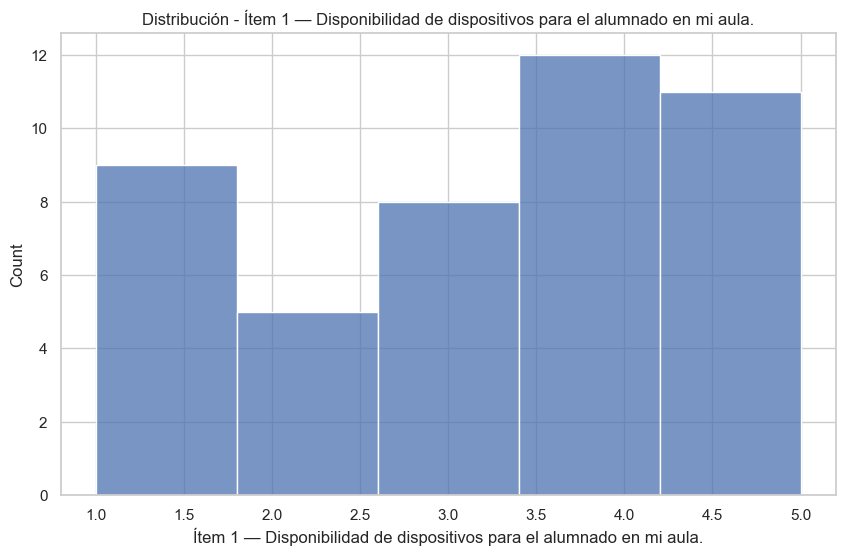

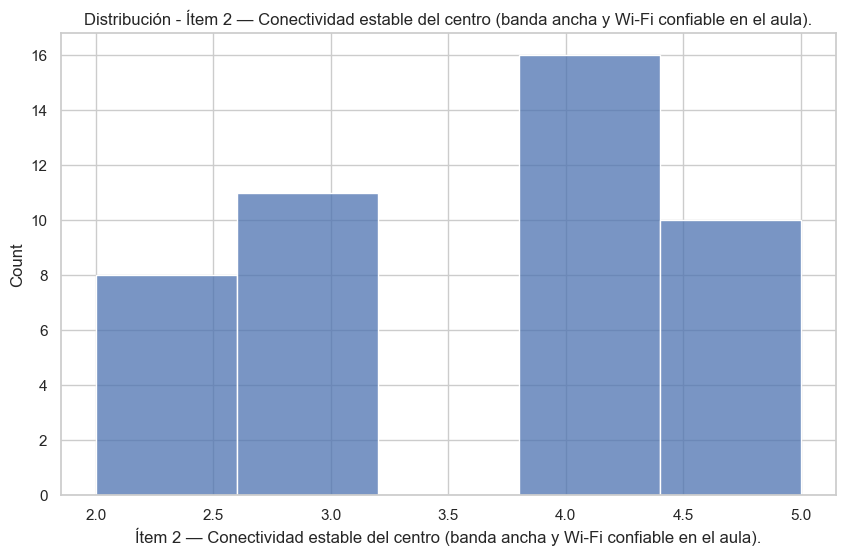

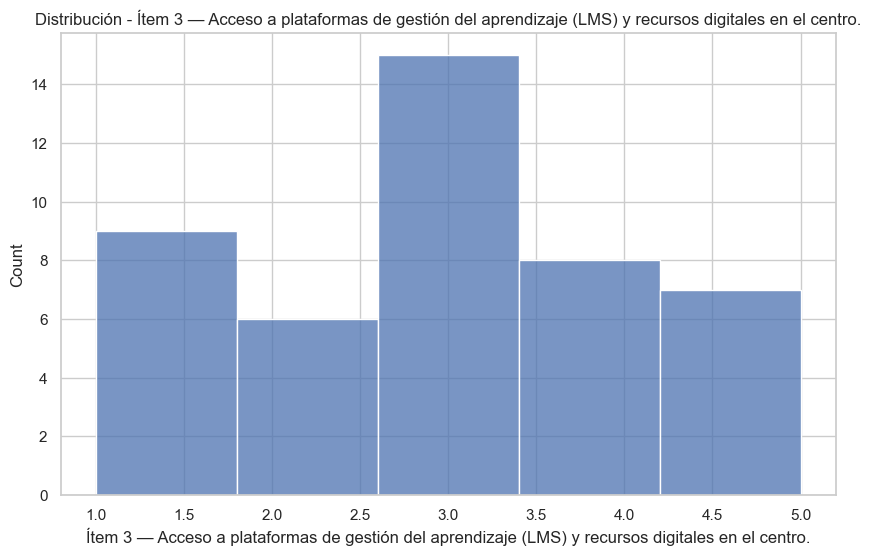

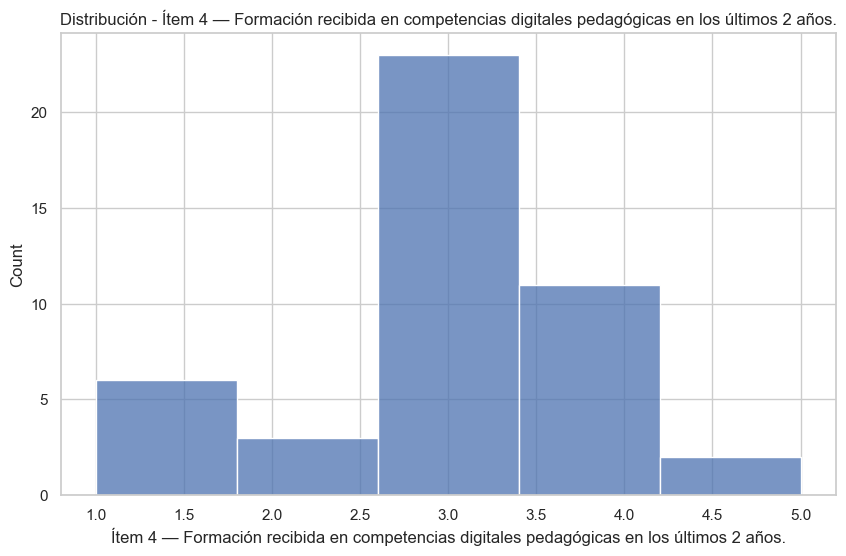

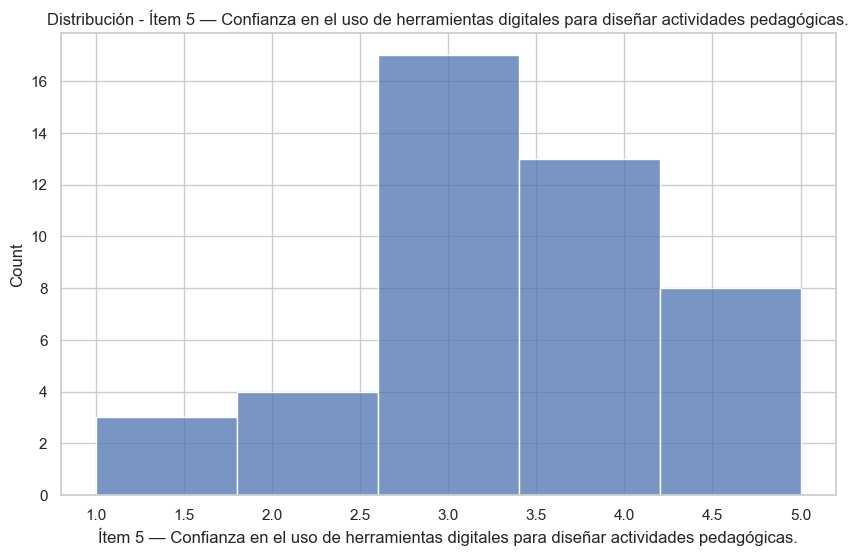

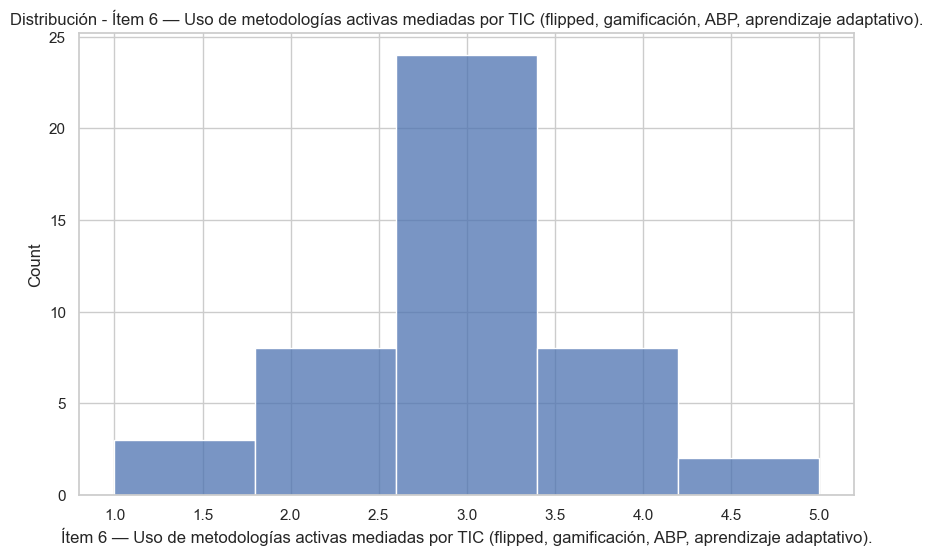

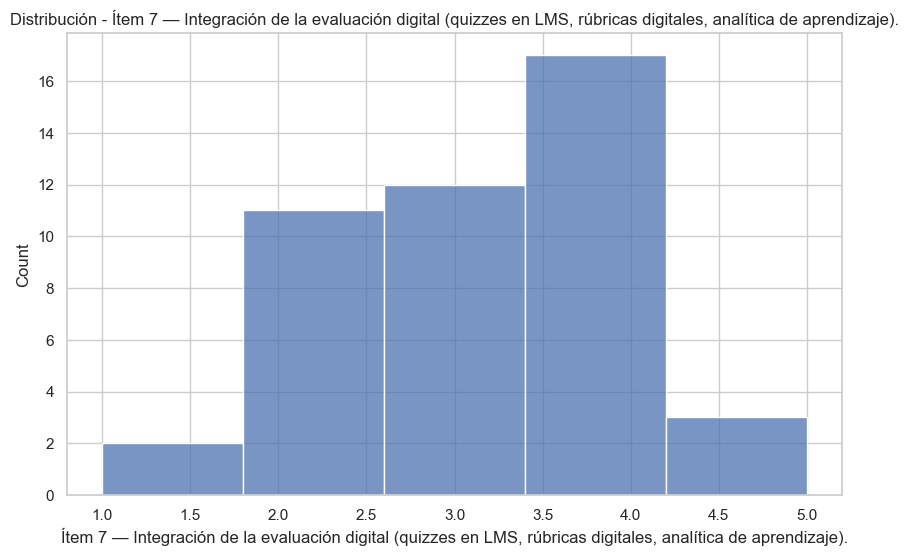

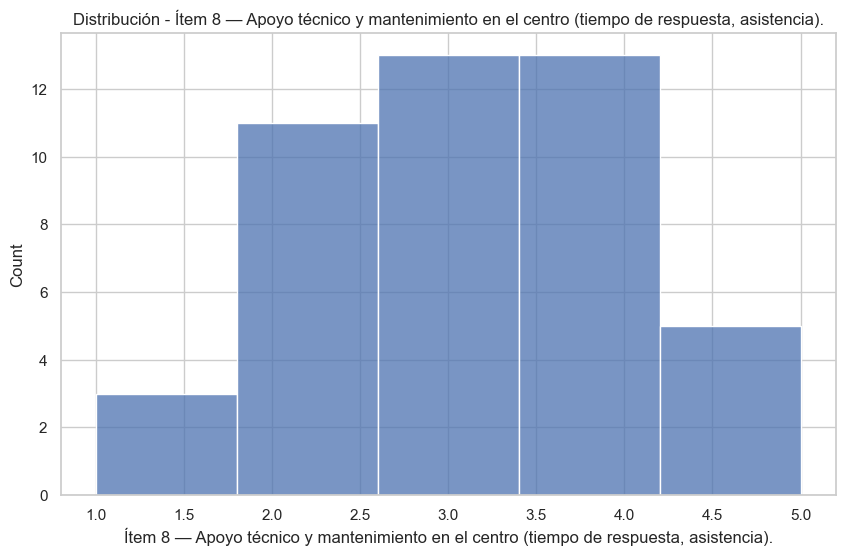

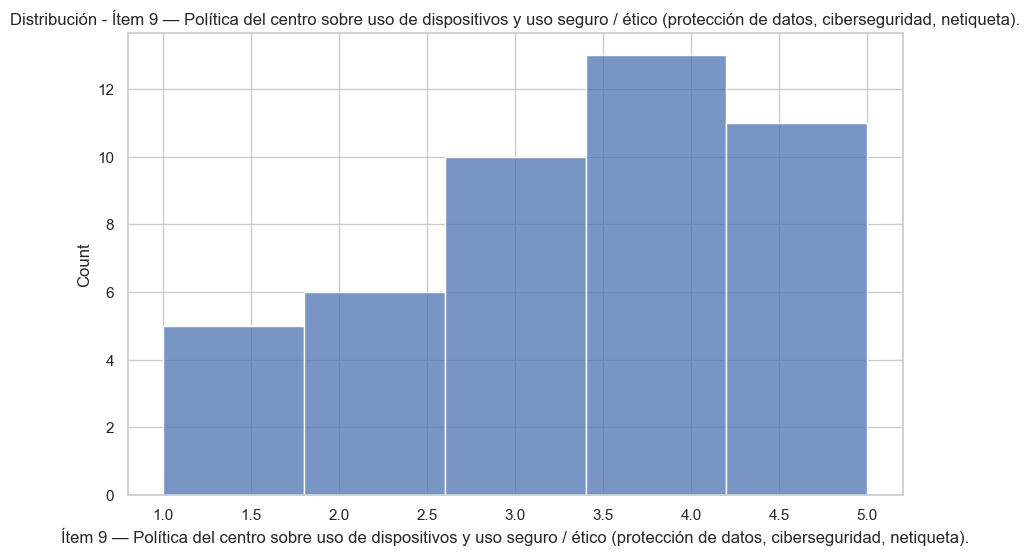

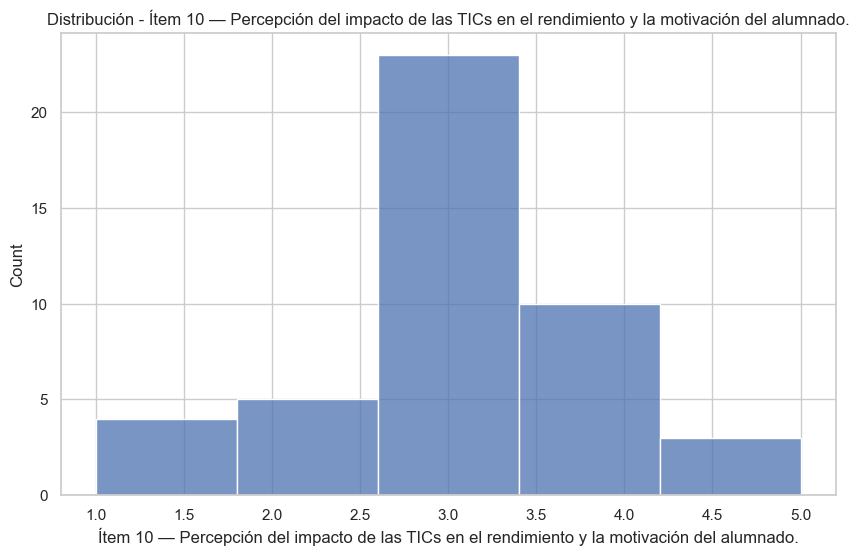

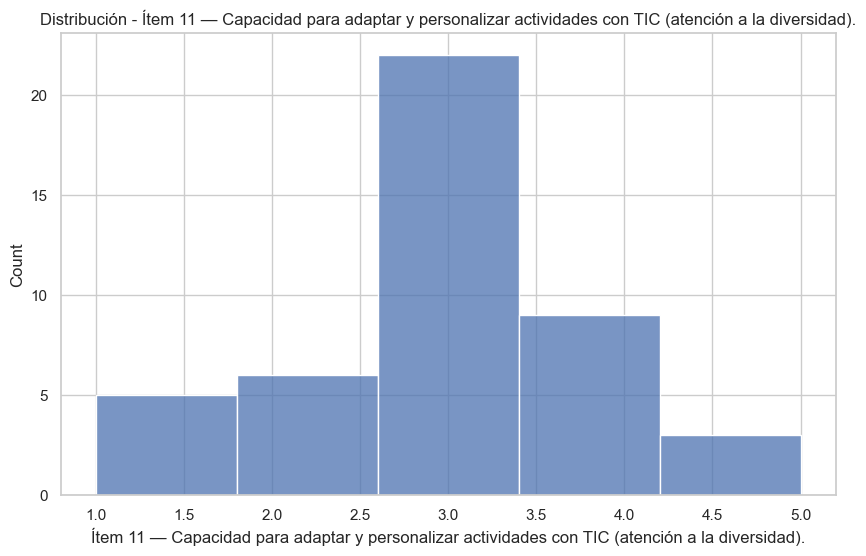

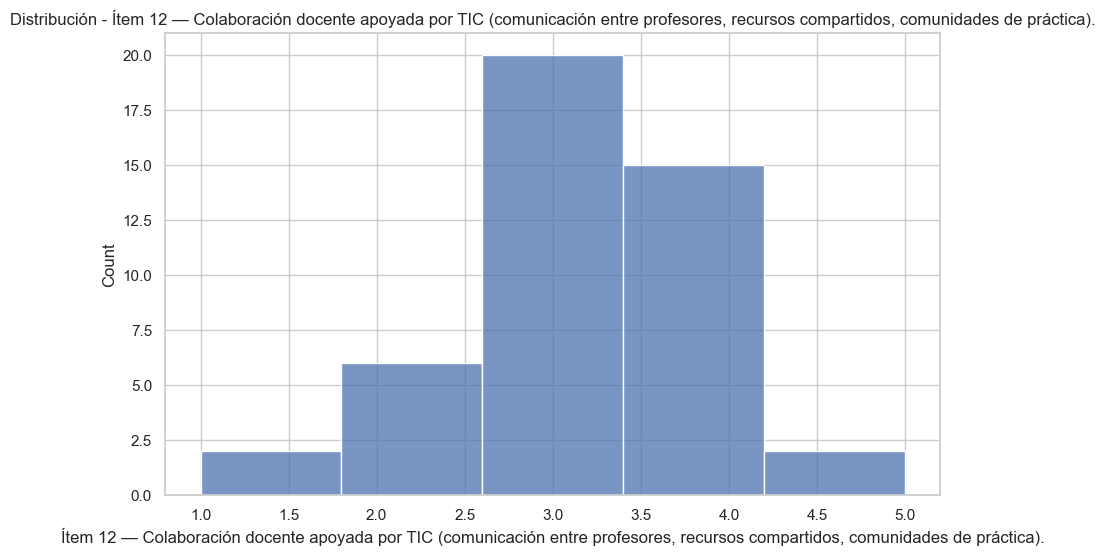

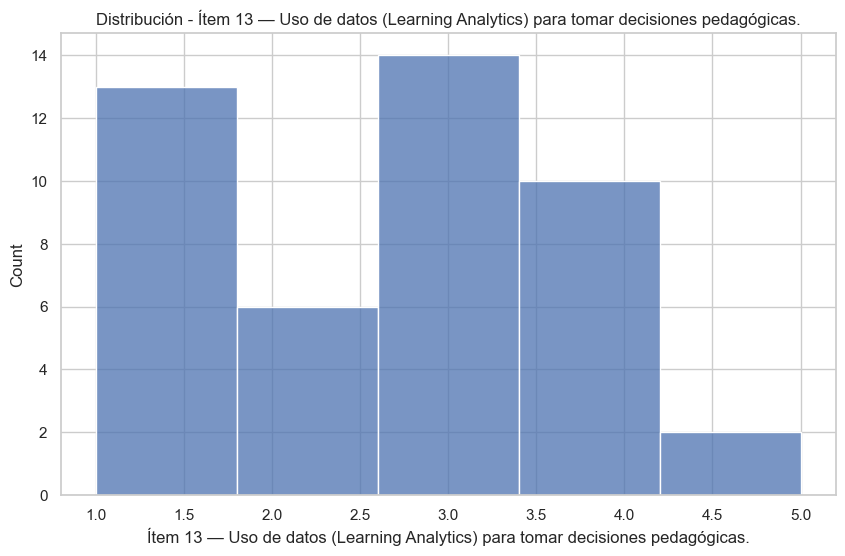

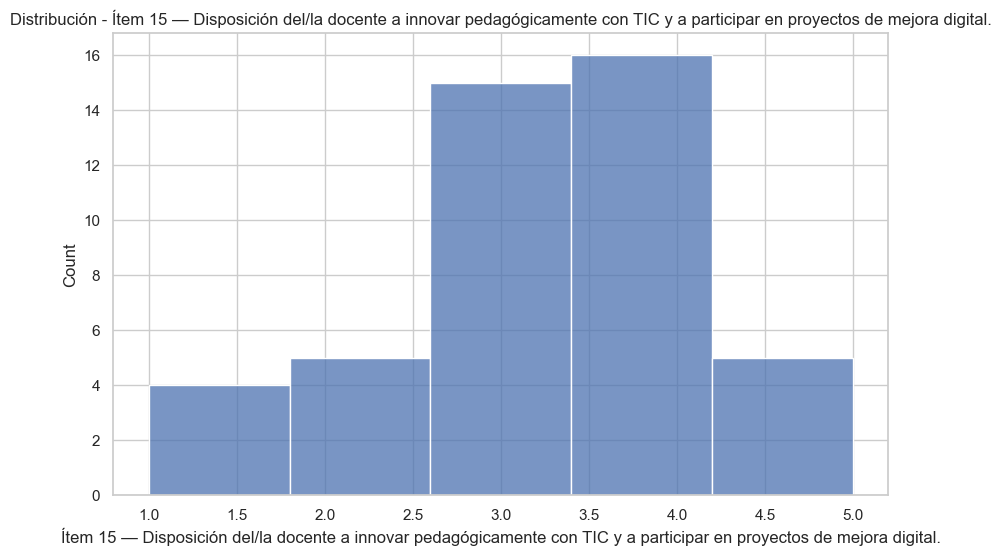

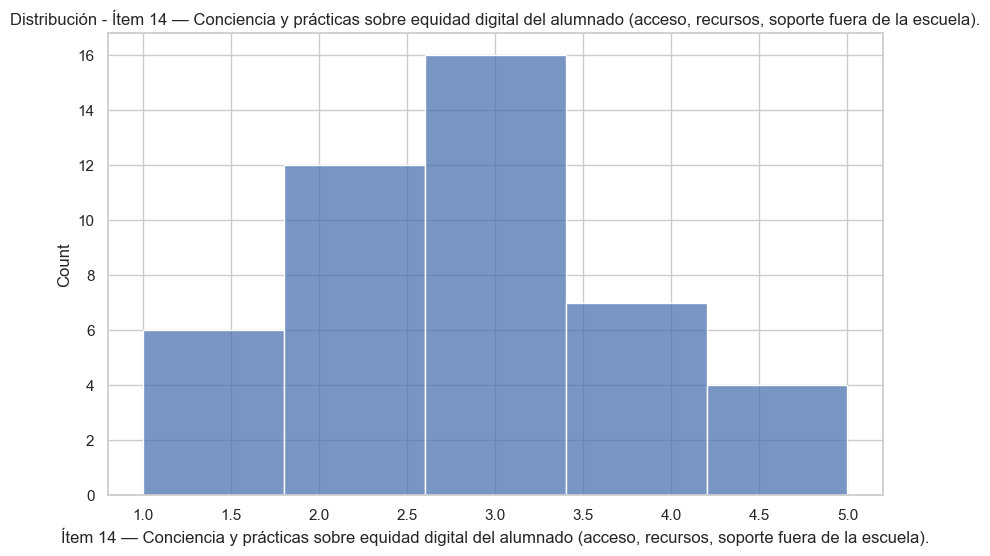

In [16]:
for col in df_likert.columns:
    sns.histplot(df_likert[col], bins=5, kde=False)
    plt.title(f"Distribución - {col}")
    plt.show()

## 3.3 Asimetría y curtosis

In [17]:
# Análisis de forma de distribución


shape_stats = pd.DataFrame({
    "Media": df_likert.mean(),
    "Desviación": df_likert.std(),
    "Asimetría": df_likert.apply(skew),
    "Curtosis": df_likert.apply(kurtosis)
})

shape_stats

,Media,Desviación,Asimetría,Curtosis
Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,3.244444,1.464047,-0.342911,-1.235304
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,3.622222,1.028876,-0.206504,-1.062433
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,2.955556,1.330679,-0.035193,-1.010001
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,3.000000,1.022475,-0.516037,0.019849
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,3.422222,1.097288,-0.373895,-0.255062
"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).",2.955556,0.903417,-0.099996,0.315098
"Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).",3.177778,1.028876,-0.234120,-0.780339
"Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).",3.133333,1.120065,-0.068480,-0.809389
"Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",3.422222,1.305389,-0.448009,-0.865936
Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,3.066667,0.986269,-0.277268,0.167569


### Criterios e Interpretación:
Permite evaluar normalidad y concentración.
>- Asimetría > 0 → concentración en valores bajos
>- Asimetría < 0 → concentración en valores altos
>- Curtosis alta → respuestas concentradas

1. **MEDIA (Nivel general de percepción)**
>- Todas las medias están entre: 2.60 y 3.62 (escala 1–5)
>- Interpretación general
>>- El punto medio teórico de la escala es 3.
>>- La mayoría de ítems están muy cerca de 3.
>>- No hay medias extremas (ni cercanas a 1 ni a 5).
>>- **Esto indica una percepción moderada / intermedia, no polarizada.**
>- **Ítems con media más alta:**
>>- Ítem 2 (Conectividad): 3.62
>>- Ítem 5 (Confianza docente): 3.42
>>- Ítem 9 (Política digital): 3.42
>>- **Interpretación:** Existe una percepción relativamente positiva en infraestructura básica y confianza docente.
>- **Ítems con media más baja:**
>>- Ítem 13 (Learning Analytics): 2.60
>>- Ítem 14 (Equidad digital): 2.80
>>- Ítem 3 (Acceso LMS): 2.96
>>- **Interpretación:** Las áreas más débiles parecen ser: (i) Uso de datos para decisiones pedagógicas, (ii) Equidad digital, (iii) Acceso efectivo a plataformas


2. **DESVIACIÓN TÍPICA (Dispersión)**
>- Las desviaciones están entre: 0.89 y 1.46
>- En una escala 1–5, esto indica:
>>- Variabilidad moderada
>>- No hay homogeneidad extrema
>>- Tampoco dispersión caótica
>- El Ítem 1 (1.46) es el más disperso → percepción muy heterogénea sobre disponibilidad de dispositivos.
>- **Esto sugiere desigualdad entre centros o contextos.**

3. **ASIMETRÍA (Skewness)**
>- Valores entre: -0.51 y +0.21
>>- **Interpretación técnica:** Valores entre -0.5 y +0.5 → distribución aproximadamente simétrica. Casi todos los ítems están en ese rango. La mayoría tienen asimetría ligeramente negativa.
>>- **Esto significa que hay un ligero sesgo hacia puntuaciones altas.** No es preocupante. No hay asimetrías fuertes (> |1|).
>- **Conclusión:** Las distribuciones son bastante equilibradas.

4. **CURTOSIS**
>- Valores mayoritariamente negativos (entre -1.23 y +0.31).
>- **¿Qué significa?**
>>- **Curtosis negativa** → distribución más plana que la normal (platicúrtica).
>- En escalas Likert esto es totalmente normal. Indica:
>>- No hay concentración extrema en el centro.
>>- No hay picos anómalos.
>>- Solo el Ítem 6 y el 10 tienen curtosis ligeramente positiva (~0.3), pero es irrelevante estadísticamente.

5. **¿Se puede asumir normalidad?**\
Técnicamente:
>- Asimetría leve
>- Curtosis moderada
>- Sin valores extremos

**Para fines descriptivos y construcción de índices:**
>- Sí, es razonable tratarlos como aproximadamente normales.
>- Implica que:
>>- Se puede calcular medias por dimensión sin distorsión.
>>- No hay ítems problemáticos.
>>- No son necesarias transformaciones.
>>- No es necesario eliminar ningún ítem por distribución anómala.

**El instrumento es estadísticamente estable.**

---
# 4. Detección de Outliers (IQR)
---
### Justificación:
Esto permite argumentar homogeneidad o dispersión en el colectivo docente.

In [18]:
Q1 = df_likert.quantile(0.25)
Q3 = df_likert.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_likert < (Q1 - 1.5 * IQR)) |
            (df_likert > (Q3 + 1.5 * IQR)))

outliers.sum()

Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.                                                               0
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).                                               0
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.                                  0
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.                                           6
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.                                       3
Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).                       21
Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).                      0
Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respue

**Este resultado indica:**
>- Algunos ítems tienen mayor concentración central.
>- Existen minorías con percepciones divergentes.
>- Especialmente en metodologías activas (Ítem 6).

**Eso es un hallazgo interesante, no un problema estadístico.** Los outliers NO se deben eliminar bajo ningún concepto en un cuestionario Likert, pues se eliminarían opiniones reales, lo cual sería metodológicamente incorrecto.

**Conclusión técnica:**
>- No hay errores de codificación
>- No hay valores fuera de rango
>- No hay necesidad de limpieza adicional
>- Dataset sigue siendo válido

---
# 5. Análisis de Consistencia Interna (Fiabilidad)
---
Calculamos Alfa de Cronbach (coeficiente de fiabilidad que mide la consistencia interna de un conjunto de ítems en una escala o test). Se utiliza para evaluar la confiabilidad y la consistencia interna de los ítems y también para determinar cuán estrechamente relacionados están los elementos de ese instrumento de recogida de datos.

La fórmula para calcular el Alfa de Cronbach es: α = (n / n-1) * (1 - ∑ Vi / VT), donde n es el número de ítems, Vi es la varianza asociada con cada ítem y VT es la varianza total de la escala. Un valor de Alfa de Cronbach cercano a 1 indica una alta consistencia interna, lo que sugiere que los ítems del test son muy similares entre sí. 

In [19]:
def cronbach_alpha(df):
    corr = df.corr()
    N = len(df.columns)
    mean_corr = corr.values[np.triu_indices(N,1)].mean()
    return (N * mean_corr) / (1 + (N - 1) * mean_corr)

alpha = cronbach_alpha(df_likert)
print("Alfa de Cronbach:", alpha)

Alfa de Cronbach: 0.9009351846079148


### Criterios e Interpretación:
>- 0.70 aceptable
>- 0.80 buena consistencia
>
Dado que el resultado es 0.90, hemos conseguido una muy buena consistencia

---
# 6. Matriz de correlaciones con significación
---
Esto permite identificar relaciones estadísticamente significativas entre ítems.

In [20]:
# Correlaciones con significación estadística

corr_matrix = df_likert.corr()

p_values = pd.DataFrame(np.zeros((len(df_likert.columns), len(df_likert.columns))),
                        columns=df_likert.columns,
                        index=df_likert.columns)

for col1 in df_likert.columns:
    for col2 in df_likert.columns:
        _, p = pearsonr(df_likert[col1], df_likert[col2])
        p_values.loc[col1, col2] = p

corr_matrix

,Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).","Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).","Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).","Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,Ítem 11 — Capacidad para adaptar y personalizar actividades con TIC (atención a la diversidad).,"Ítem 12 — Colaboración docente apoyada por TIC (comunicación entre profesores, recursos compartidos, comunidades de práctica).",Ítem 13 — Uso de datos (Learning Analytics) para tomar decisiones pedagógicas.,Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital.,"Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela)."
Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,1.000000,0.123050,0.122363,-0.060729,0.188944,0.266149,0.151550,0.270723,0.230175,0.271772,0.078790,-0.020827,-0.007449,0.265615,0.288640
Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,0.123050,1.000000,0.336060,0.021604,0.245150,0.470545,0.236641,0.636349,0.493738,0.450925,0.184325,0.405026,0.533486,0.279341,0.379725
Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,0.122363,0.336060,1.000000,0.200448,0.417838,0.470955,0.371105,0.507271,0.429730,0.383288,0.362910,0.294069,0.426148,0.428176,0.548256
Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,-0.060729,0.021604,0.200448,1.000000,0.445653,0.467477,0.151227,0.138915,0.170277,0.135223,0.408722,0.298216,0.408841,0.303093,0.097475
Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,0.188944,0.245150,0.417838,0.445653,1.000000,0.684230,0.535930,0.212041,0.428049,0.561415,0.589770,0.398300,0.523415,0.781592,0.432347
"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).",0.266149,0.470545,0.470955,0.467477,0.684230,1.000000,0.399909,0.545037,0.459522,0.641082,0.485851,0.433147,0.587454,0.630678,0.410394
"Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).",0.151550,0.236641,0.371105,0.151227,0.535930,0.399909,1.000000,0.314230,0.467415,0.324009,0.452736,0.182756,0.356835,0.535925,0.166614
"Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).",0.270723,0.636349,0.507271,0.138915,0.212041,0.545037,0.314230,1.000000,0.597928,0.362094,0.120443,0.290382,0.347256,0.263158,0.359488
"Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",0.230175,0.493738,0.429730,0.170277,0.428049,0.459522,0.467415,0.597928,1.000000,0.507222,0.394653,0.471062,0.426050,0.387936,0.485582
Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,0.271772,0.450925,0.383288,0.135223,0.561415,0.641082,0.324009,0.362094,0.507222,1.000000,0.514419,0.370996,0.501248,0.735970,0.537603


1. **Visión general de la matriz**\
**Observaciones globales:**
>- Todas las correlaciones son positivas o cercanas a 0.
>- No hay correlaciones negativas relevantes.
>- Existen varias correlaciones fuertes (> 0.60).
>- No hay correlaciones extremas (> 0.90).

**Esto es ideal, significa:**
>- Coherencia conceptual.
>- Ausencia de multicolinealidad severa.
>- No hay redundancia extrema entre ítems.

2. **Hallazgos más importantes:**
>- A. Núcleo fuerte: **Competencia docente e innovación**
>- Correlaciones más altas:
>>- Ítem 5 ↔ Ítem 15 → 0.78
>>- Ítem 10 ↔ Ítem 15 → 0.73
>>- Ítem 5 ↔ Ítem 6 → 0.68
>>- Ítem 11 ↔ Ítem 15 → 0.66
>>- Ítem 6 ↔ Ítem 10 → 0.64

**Interpretación:**\
Existe un bloque claramente cohesionado que conecta:
>- Confianza digital
>- Uso de metodologías activas
>- Innovación pedagógica
>- Percepción de impacto
>- Personalización

**Esto sugiere que la competencia docente es el núcleo explicativo del modelo.**
>- No es la infraestructura.Es la dimensión pedagógica.
>- **Esto es un hallazgo muy fuerte de cara al proyecto y la discusión de los resultados a nivel micro.**

>- B. **Infraestructura y gobernanza**
>- Correlaciones relevantes:
>>- Ítem 2 ↔ Ítem 8 → 0.63
>>- Ítem 8 ↔ Ítem 9 → 0.59
>>- Ítem 2 ↔ Ítem 9 → 0.49

**Interpretación:**
>- La conectividad, el soporte técnico y la política digital están interrelacionados.
>- Esto confirma **coherencia estructural de la dimensión organizativa.**

>- C. **Uso de datos (Learning Analytics)**
>>- Ítem 13 correlaciona moderadamente con:
>>- Ítem 6 → 0.59
>>- Ítem 11 → 0.55
>>- Ítem 12 → 0.54
>>- Ítem 15 → 0.53

**Interpretación:**
>- El uso de datos no es independiente.
>- Está vinculado a **docentes innovadores y metodologías activas.**

**Indica que el análisis de datos es parte del perfil docente avanzado.**

>- D. **Infraestructura básica (Ítem 1)**
>>- Ítem 1 presenta correlaciones bajas-moderadas (0.07–0.29).

**Interpretación clave:**
>- La disponibilidad de dispositivos no es el principal motor de integración TIC.

**Esto es un hallazgo muy interesante:** Sugiere que la **variable determinante** no es el equipamiento, sino la **competencia y la cultura pedagógica.**

---
# 7. Estandarización y Normalización del dataset
---

### Justificación metodológica
La escala Likert es ordinal, pero:
>- Para análisis comparativo y dashboard
>- Para futuros modelos de clustering
>- Para agregación de índices compuestos

**Procedemos a:**
1. Estandarización Z-score
2. Normalización MinMax (0–1)

Si bien, antes de proceder a la normnalización del dataset, se realizará la agregación intra-dimensión, pues el índice conceptual se construye por dimensiones teóricas, no por ítems aislados (consultar documento TFM - **Figura 17.** *Proceso de construcción del Índice Sintético de Digitalización Educativa (ISDE), de carácter cíclico e iterativo.*).\
En el siguiente epígrafe se procede a la susoduicha agrupación por dimensiones conceptuales.

In [21]:
# 7.1 Z-score
scaler = StandardScaler()
df_std = pd.DataFrame(
    scaler.fit_transform(df_likert),
    columns=df_likert.columns
)

df_std.head()

,Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.,Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).,Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.,Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.,Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.,"Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).","Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).","Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia).","Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.,Ítem 11 — Capacidad para adaptar y personalizar actividades con TIC (atención a la diversidad).,"Ítem 12 — Colaboración docente apoyada por TIC (comunicación entre profesores, recursos compartidos, comunidades de práctica).",Ítem 13 — Uso de datos (Learning Analytics) para tomar decisiones pedagógicas.,Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital.,"Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela)."
0,-1.550364,-1.594510,0.033777,0.000000,0.532501,-1.069665,-2.140575,-1.926174,-0.327100,-1.093737,1.000473,0.904534,0.323498,-0.265583,0.177394
1,1.212661,-1.594510,-1.486198,0.000000,0.532501,0.049752,0.808176,-1.023280,-1.101812,-0.068359,-0.956974,-1.356801,0.323498,0.653742,-1.596543
2,1.212661,1.354241,1.553753,0.000000,0.532501,1.169169,0.808176,-0.120386,1.222323,0.957020,1.000473,0.904534,1.132244,0.653742,1.064362
3,0.521905,-0.611593,0.033777,0.989071,-0.389135,0.049752,-0.174741,0.782508,0.447611,-0.068359,0.021749,0.904534,0.323498,-0.265583,1.064362
4,0.521905,0.371324,0.033777,0.000000,-0.389135,0.049752,0.808176,-0.120386,0.447611,-0.068359,0.021749,-0.226134,1.132244,-0.265583,0.177394


---
# 8. Creación de índices estratégicos
---

**Agrupamos dimensiones conceptuales:**
>- Infraestructura (Ítems 1–3)
>- Competencia docente (Ítems 4–7)
>- Gobernanza y apoyo (Ítems 8–9)
>- Cultura digital (Ítems 10–15)
>
**¿Qué se está haciendo exactamente el siguiente script?**\
Se está calculando: *dimensión = suma ítems/nº ítems*\
Es decir:
>- Promedio simple
>- Ponderación igualitaria
>- Construcción aditiva
>
**¿Por qué es correcto metodológicamente?**\
Porque:
>- Las dimensiones provienen de un modelo conceptual previo.
>- Los ítems dentro de cada dimensión miden el mismo constructo.
>- No se han aplicado ponderaciones diferenciales (lo cual sería otra decisión metodológica).

**Esto construye subíndices.**

In [22]:
df_indices = pd.DataFrame()

# 1. Infraestructura digital escolar
infraestructura_cols = [
    "Ítem 1 — Disponibilidad de dispositivos para el alumnado en mi aula.",
    "Ítem 2 — Conectividad estable del centro (banda ancha y Wi-Fi confiable en el aula).",
    "Ítem 3 — Acceso a plataformas de gestión del aprendizaje (LMS) y recursos digitales en el centro.",
    "Ítem 8 — Apoyo técnico y mantenimiento en el centro (tiempo de respuesta, asistencia)."
]

df_indices["Infraestructura_Digital"] = df_likert[infraestructura_cols].mean(axis=1)


# 2. Competencia digital docente
competencia_cols = [
    "Ítem 4 — Formación recibida en competencias digitales pedagógicas en los últimos 2 años.",
    "Ítem 5 — Confianza en el uso de herramientas digitales para diseñar actividades pedagógicas.",
    "Ítem 11 — Capacidad para adaptar y personalizar actividades con TIC (atención a la diversidad)."
]

df_indices["Competencia_Digital_Docente"] = df_likert[competencia_cols].mean(axis=1)


# 3. Uso pedagógico de TIC
uso_tic_cols = [
    "Ítem 6 — Uso de metodologías activas mediadas por TIC (flipped, gamificación, ABP, aprendizaje adaptativo).",
    "Ítem 7 — Integración de la evaluación digital (quizzes en LMS, rúbricas digitales, analítica de aprendizaje).",
    "Ítem 12 — Colaboración docente apoyada por TIC (comunicación entre profesores, recursos compartidos, comunidades de práctica)."
]

df_indices["Uso_Pedagogico_TIC"] = df_likert[uso_tic_cols].mean(axis=1)


# 4. Liderazgo y estrategia institucional
liderazgo_cols = [
    "Ítem 9 — Política del centro sobre uso de dispositivos y uso seguro / ético (protección de datos, ciberseguridad, netiqueta).",
    "Ítem 15 — Disposición del/la docente a innovar pedagógicamente con TIC y a participar en proyectos de mejora digital."
]

df_indices["Liderazgo_Estrategia"] = df_likert[liderazgo_cols].mean(axis=1)


# 5. Equidad digital y resultados educativos
equidad_cols = [
    "Ítem 10 — Percepción del impacto de las TICs en el rendimiento y la motivación del alumnado.",
    "Ítem 13 — Uso de datos (Learning Analytics) para tomar decisiones pedagógicas.",
    "Ítem 14 — Conciencia y prácticas sobre equidad digital del alumnado (acceso, recursos, soporte fuera de la escuela)."
]

df_indices["Equidad_Resultados"] = df_likert[equidad_cols].mean(axis=1)


df_indices.head()

,Infraestructura_Digital,Competencia_Digital_Docente,Uso_Pedagogico_TIC,Liderazgo_Estrategia,Equidad_Resultados
0,1.75,3.666667,2.333333,3.0,2.666667
1,2.50,3.000000,3.000000,3.0,2.333333
2,4.50,3.666667,4.000000,4.5,4.000000
3,3.50,3.333333,3.333333,3.5,3.333333
4,3.50,3.000000,3.333333,3.5,3.333333


Y ahora, procedemos a la **normalización de las dimensiones**.

## 7.2 Normalización de las dimensiones

**¿Qué hace matemáticamente el siguiente script?**\
Para cada dimensión: *x' = (x-mín)/(máx-mín)*\
Transforma la escala original (1–5) en: *x' un valor del intervalo cerrado [0,1]*.

**¿Por qué es crucial?**\
Porque:
>- Permite comparar dimensiones en la misma escala.
>- Facilita interpretación visual en Power BI.
>- Hace el índice final interpretable como porcentaje relativo.
>>-  0 = menor nivel observado
>>-  1 = mayor nivel observado

In [23]:
# 7.2 Normalización 0-1
scaler = MinMaxScaler()

df_indices_norm = pd.DataFrame(
    scaler.fit_transform(df_indices),
    columns=df_indices.columns
)

df_indices_norm.head()

,Infraestructura_Digital,Competencia_Digital_Docente,Uso_Pedagogico_TIC,Liderazgo_Estrategia,Equidad_Resultados
0,0.133333,0.636364,0.3,0.500,0.454545
1,0.333333,0.454545,0.5,0.500,0.363636
2,0.866667,0.636364,0.8,0.875,0.818182
3,0.600000,0.545455,0.6,0.625,0.636364
4,0.600000,0.454545,0.6,0.625,0.636364


---
# 9. Alfa de Cronbach para cada una de las 5 dimensiones
---
Cálculo usando los ítems originales (df_likert), no los índices ya promediados.\
El alfa se calcula sobre los ítems, no sobre la media de la dimensión.

<div align="center">

### Interpretación académica

</div>

| Alfa        | Interpretación |
| ----------- | -------------- |
| > 0.90      | Excelente      |
| 0.80 – 0.89 | Muy buena      |
| 0.70 – 0.79 | Aceptable      |
| 0.60 – 0.69 | Cuestionable   |
| < 0.60      | Débil          |


In [24]:
# Definimos primero la función:
def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    variances = df.var(axis=0, ddof=1)
    total_variance = df.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_variance)
    return alpha

# 1. Infraestructura digital escolar
alpha_infraestructura = cronbach_alpha(df_likert[infraestructura_cols])
alpha_infraestructura

# 2. Competencia digital docente
alpha_competencia = cronbach_alpha(df_likert[competencia_cols])
alpha_competencia

# 3. Uso pedagógico de TIC
alpha_uso_tic = cronbach_alpha(df_likert[uso_tic_cols])
alpha_uso_tic

# 4. Liderazgo y estrategia institucional
alpha_liderazgo = cronbach_alpha(df_likert[liderazgo_cols])
alpha_liderazgo

# 5. Equidad digital y resultados educativos
alpha_equidad = cronbach_alpha(df_likert[equidad_cols])
alpha_equidad

print("Infraestructura:", alpha_infraestructura)
print("Competencia:", alpha_competencia)
print("Uso pedagógico TIC:", alpha_uso_tic)
print("Liderazgo:", alpha_liderazgo)
print("Equidad y resultados:", alpha_equidad)

Infraestructura: 0.6333418490448209
Competencia: 0.7366341236634122
Uso pedagógico TIC: 0.5993197278911564
Liderazgo: 0.553159478435306
Equidad y resultados: 0.7017654476670868


<div align="center">

### RESULTADO

</div>

| Dimensión                   | Alfa de Cronbach | Nivel                       |
| --------------------------- | ---------------- | --------------------------- |
| Infraestructura             | 0.633            | Cuestionable–Aceptable baja |
| Competencia digital docente | 0.737            | Aceptable                   |
| Uso pedagógico TIC          | 0.599            | Baja                        |
| Liderazgo y estrategia      | 0.553            | Baja                        |
| Equidad y resultados        | 0.702            | Aceptable                   |

1. **Infraestructura digital escolar (α = 0.633)**
>- **Interpretación:**
>>- Nivel moderado-bajo pero aceptable en estudios exploratorios.
>>- Hay coherencia, pero no fuerte homogeneidad.
>- Puede indicar que:
>>- Disponibilidad de dispositivos
>>- Conectividad
>>- LMS
>>- Soporte técnico
>>  no siempre evolucionan al mismo ritmo en los centros.

>- **Conclusión**
>>- Defendible
>>- No requiere eliminación inmediata de ítems
>>- Puede mejorarse en futuros instrumentos

2. **Competencia digital docente (α = 0.737)**
>- **Interpretación:**
>>- Buena consistencia.
>>- Formación, confianza y personalización están alineadas.
>>- Es una dimensión sólida.

>- **Conclusión:**
>- Dimensión robusta
>- Metodológicamente estable
>- No requiere ajustes

3. **Uso pedagógico de TIC (α = 0.599)**
>- **Interpretación:**
>>- Está justo por debajo del umbral 0.60.
>>- **Indica heterogeneidad entre: Metodologías activas, evaluación digital y colaboración docente.** Es probable que un docente use metodologías activas, pero no necesariamente evaluación digital, o no colabore digitalmente. **Es decir: son prácticas relacionadas, pero no idénticas.**

>- **Conclusión:**
>>- Dimensión débil pero defendible en estudio exploratorio
>>- Podría mejorarse revisando correlaciones internas
>>- No es catastrófica

4. **Liderazgo y estrategia institucional (α = 0.553)**\
**MUY IMPORTANTE:**\
Esta dimensión tiene solo **2 ítems.**

>- **Clave estadística:**
>>- El **alfa de Cronbach penaliza fuertemente escalas con 2 ítems.** Con dos ítems, el alfa depende casi exclusivamente de su correlación directa, por eso **valores de 0.50–0.60 son habituales en escalas breves.**

>- **Conclusión:**
>>- Bajo, pero matemáticamente esperable
>>- No invalida la dimensión
>>- Se puede justificar por número reducido de ítems

5. **Equidad y resultados (α = 0.702)**
>- **Interpretación:**
>>- Consistencia aceptable.
>>- Impacto, uso de datos y equidad están moderadamente alineados.
>>- Dimensión defendible.

>- **Conclusión:**
>>- Correcta
>>- Estable
>>- Publicable en estudio exploratorio

### VISIÓN GLOBAL DEL INSTRUMENTO
**Recordemos: Alfa global del instrumento completo = 0.909**\
**Eso significa que:**
>- El modelo general es muy sólido.
>- Las dimensiones individuales muestran distinta intensidad interna.
>- No hay incoherencias graves.
>- No hay necesidad urgente de eliminar ítems.

**CONCLUSIÓN:**\
NO es necesario modificar el instrumento. Ya que:
>- Es un estudio exploratorio
>- Las dimensiones son conceptualmente sólidas
>- El alfa global es excelente.
>- Las dimensiones más bajas son explicables estadísticamente.

---
# 10. Creación del ISDE
---
**¿Qué está haciendo el siguiente script?**\
Construyendo el índice sintético final como: *ISDE = (suma de cada dimensión)/4*\
Es un modelo:
>- Aditivo
>- No ponderado
>- Lineal

**¿Qué implica esto conceptualmente?**\
Se está asumiendo que:
>- Las 5 dimensiones tienen el mismo peso estructural.
>- No existe jerarquía entre ellas.
>- El desarrollo digital es sistémico.

In [25]:
df_indices_norm.columns


Index(['Infraestructura_Digital', 'Competencia_Digital_Docente',
       'Uso_Pedagogico_TIC', 'Liderazgo_Estrategia', 'Equidad_Resultados'],
      dtype='object')

In [26]:
df_indices_norm = (df_indices - df_indices.min()) / (df_indices.max() - df_indices.min())

In [27]:
df_indices_norm["ISDE"] = df_indices_norm.mean(axis=1)
df_indices_norm.head()

,Infraestructura_Digital,Competencia_Digital_Docente,Uso_Pedagogico_TIC,Liderazgo_Estrategia,Equidad_Resultados,ISDE
0,0.133333,0.636364,0.3,0.500,0.454545,0.404848
1,0.333333,0.454545,0.5,0.500,0.363636,0.430303
2,0.866667,0.636364,0.8,0.875,0.818182,0.799242
3,0.600000,0.545455,0.6,0.625,0.636364,0.601364
4,0.600000,0.454545,0.6,0.625,0.636364,0.583182


---
# 11. Dataset final para dashborad: Exportación para Power BI
---

In [28]:
# 1) Dataset ejecutivo
df_indices_norm.round(2).to_csv(
    "dataset_procesado_cuestionario_ISDE_TFM_TIC.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

# 2) Dataset completo
df_final = pd.concat([df_indices_norm, df_likert], axis=1)
df_final.round(2).to_csv(
    "Dataset_procesado_completo_con_items_ISDE_TFM.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

1. Para análisis interno y Power BI avanzado → el completo
2. Para mostrar resultados finales → el sintético

**No es excluyente.**

---
# 12. Hallazgos importantes:
---
>- El **análisis de forma de distribución** muestra que los ítems presentan medias cercanas al punto medio teórico de la escala (3), lo que indica una percepción moderada del grado de integración TIC. La dispersión es moderada, evidenciando variabilidad entre participantes sin polarización extrema. Los **coeficientes de asimetría y curtosis** se sitúan dentro de rangos aceptables (-1 a +1), lo que sugiere distribuciones aproximadamente simétricas y sin presencia de colas pronunciadas. En conjunto, los resultados respaldan la estabilidad estadística del instrumento y permiten proceder a la construcción de dimensiones agregadas sin necesidad de transformaciones adicionales.
>- El análisis de valores atípicos mediante el **criterio del rango intercuartílico** identificó ciertos casos clasificados como extremos en algunos ítems. No obstante, dado que las variables corresponden a una escala Likert ordinal de rango reducido (1–5), estos valores no constituyen errores ni anomalías, sino respuestas legítimas situadas en categorías extremas. Por tanto, no se procedió a su eliminación, preservando la integridad de las percepciones recogidas.
>- El análisis de consistencia interna mediante el **coeficiente Alfa de Cronbach** arrojó un valor de 0.901, lo que indica una fiabilidad excelente del instrumento. Este resultado evidencia una alta coherencia interna entre los ítems y respalda la validez de su agregación en dimensiones compuestas e índices sintéticos para el análisis posterior.
>- Como resultado de la matriz de correlaciones entre los ítems del cuestionario: **La competencia docente y la innovación explican más la integración TIC que la infraestructura.**
>- Se calculó el coeficiente Alfa de Cronbach para cada dimensión del instrumento con el fin de evaluar su consistencia interna. Los resultados evidencian niveles adecuados de fiabilidad, especialmente en las dimensiones con mayor número de ítems, confirmando la coherencia interna del modelo estructural propuesto.
>- El análisis de consistencia interna por dimensiones mostró niveles variables de fiabilidad. La dimensión Competencia digital docente (α = 0.737) y Equidad y resultados educativos (α = 0.702) presentan consistencia aceptable. Infraestructura digital escolar mostró una consistencia moderada (α = 0.633), mientras que Uso pedagógico de TIC (α = 0.599) y Liderazgo y estrategia institucional (α = 0.553) presentaron niveles más bajos. En el caso de esta última, el reducido número de ítems (k = 2) puede explicar la menor estabilidad del coeficiente. **Globalmente, el instrumento presenta una fiabilidad excelente (α ≈ 0.90), lo que respalda su coherencia estructural.**